Веб разработка - создание и обслуживание сайтов, сервисов, API

Веб-приложение состоит из клиентской и серверной части

Для ускорения разработки бекенда используются web-фреймворки: наборы пакетов и модулей с готовыми компонентами приложения. Самые известные web-фреймворки для Python - django, flask, fastapi, aiohttp

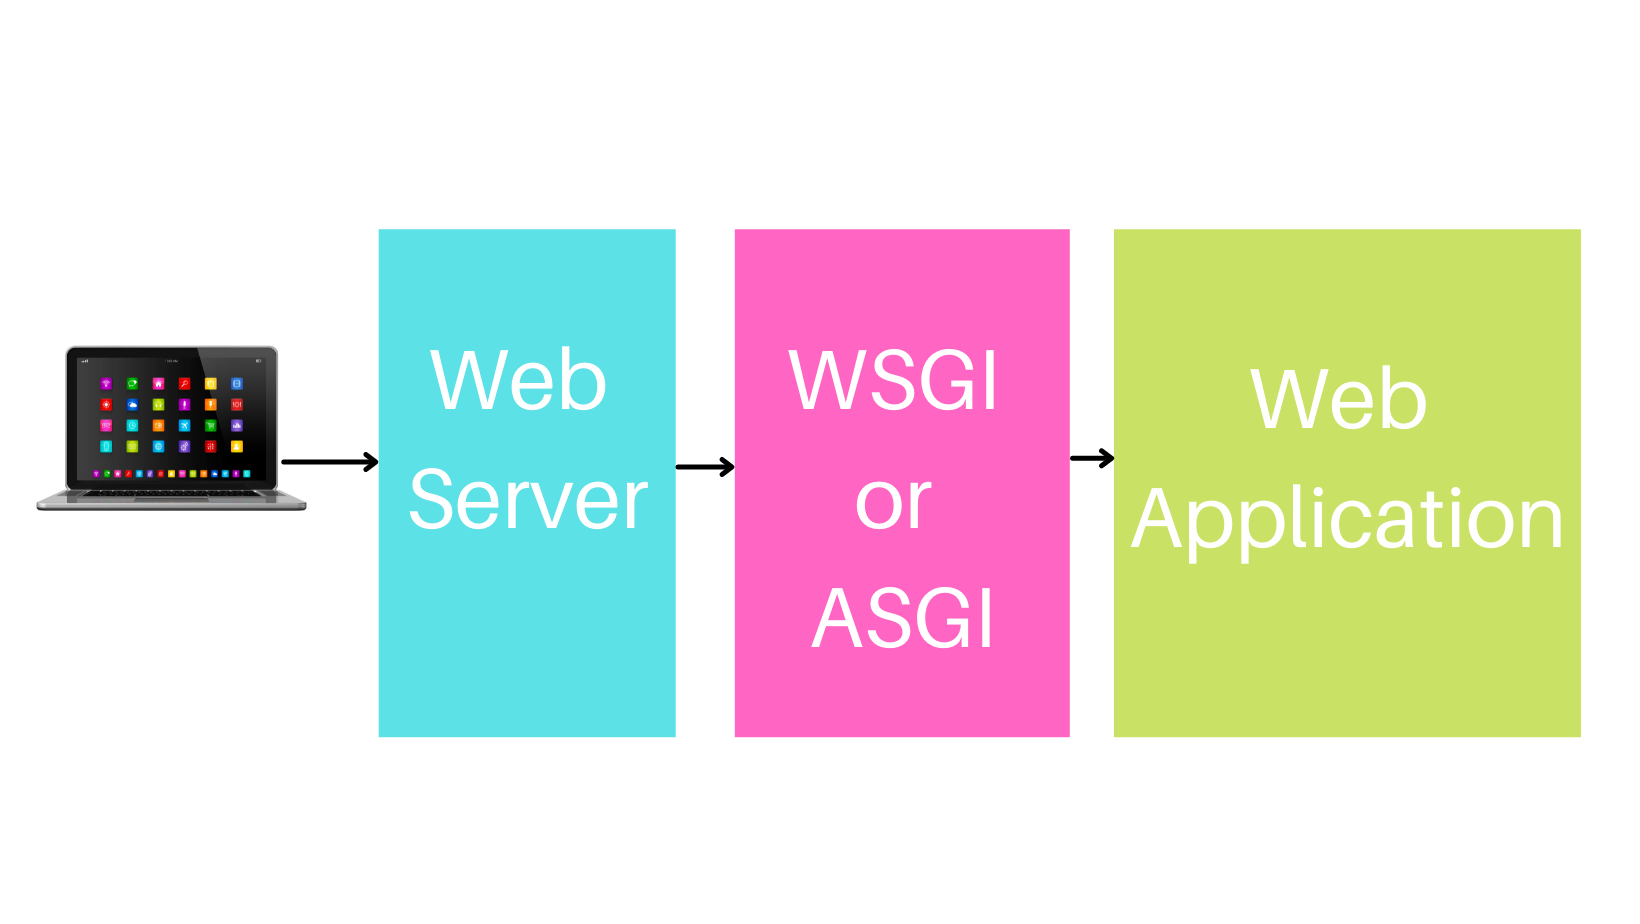

WSGI (англ. Web Server Gateway Interface) — стандарт взаимодействия между Python-программой, выполняющейся на стороне сервера, и самим веб-сервером. WSGI предоставляет простой и универсальный интерфейс между большинством веб-серверов и веб-приложениями или фреймворками. WSGI-приложение должно удовлетворять следующим требованиям:
- должно быть вызываемым объектом (обычно это функция или метод)
- принимать два параметра:
  - словарь переменных окружения
  - обработчик запроса
- вызывать обработчик запроса с кодом HTTP-ответа и HTTP-заголовками
- возвращать итерируемый объект с телом ответа

ASGI (англ. Asynchronous Server Gateway Interface) — клиент-серверный протокол взаимодействия веб-сервера и приложения. По сравнению с WSGI предоставляет стандарт как для асинхронных, так и для синхронных приложений, с реализацией обратной совместимости WSGI и несколькими серверами и платформами приложений. ASGI предоставляет доступ к функциям, которые невозможно реализовать средствами WSGI.

Flask построен на Werkzeug WSGI сервере. Имеет поддержку псевдоасинхронного выполнения - запрос может быть запушен в Цикле событий (только asyncio) внутри отдельного потока.

Fastapi имеет полную поддерку ASGI, может быть запущен на любом ASGI сервере.

Aiohttp имеет собственную реализацию асинхронного сервера, не поддерживает стандарт ASGI. Каждая ручка (handler) должна быть корутиной, принимающей на вход запрос Request и возращающей ответ Response.

Разработка высоконагруженного веб-приложения:
1. Анализ и сбор требований. Описываются функциональные требования, то есть то что должно делать приложение, описываются сценарии использования от бизнеса
2. Высокоуровневая архитектура. База данных, архитектура, метрики или оценка состояния системы.
3. Реализация. Зависит от архитектуры, разрабатываем интерфейс сервисов (контракты взаимодействия). Сервисы могут взаимодействовать между собой с помощью API - синхронного или асинхронного; с помощью шины данных (databus) и событий, пишем бизнес-логику каждого сервиса, учитываем сложные технические вопросы
4. Тестирование. Автоматическое, AB тестирование, канареечные деплои.
5. Развертывание
6. Сопровождение и документирование.

### Асинхронный способ взаимодействия с сервисом (паттерн)

Синхронный подход (одна ручка). При синхронной обработке долгого пользовательского запроса клиент вынужден держать соединение открытым всё время, пока сервер выполняет тяжёлую операцию (например, обработка видео, построение отчёта, рассылка писем). Это приводит к таймаутам, блокировке воркеров и быстрому исчерпанию ресурсов при высокой нагрузке.

Асинхронный подход с отложенным результатом (две ручки). Вместо этого используется асинхронное API: первая ручка принимает запрос, мгновенно возвращает идентификатор задачи и запускает долгий процесс в фоне. Вторая ручка принимает этот идентификатор и возвращает либо статус выполнения, либо готовый результат. Клиент сам решает, когда и как часто проверять результат — соединения не висят подолгу, сервер остаётся отзывчивым. Это избавляет от таймаутов и позволяет клиенту получать результат когда угодно.